weighted polyfit (weights from distance uncertainty only):
slope = 1.897e+08 ± 1.4e+06 m/s
intercept = -4.480e-02 ± 1.5e-02 m
v/c = 0.633 ± 0.005

odr fit (uses time and distance uncertainties):
slope = 1.917e+08 ± 1.7e+06 m/s
intercept = -4.751e-02 ± 2.8e-02 m
v/c = 0.640 ± 0.006

chi-square for weighted polyfit (using y uncertainties):
chi^2 = 6.66
ndof = 8
chi^2/ndof = 0.83
p-value = 0.574


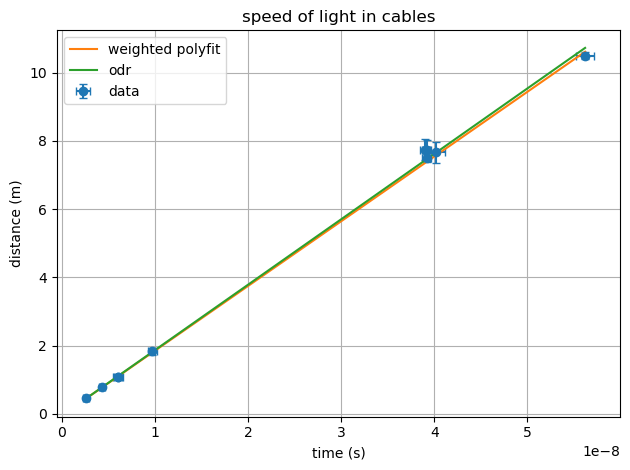

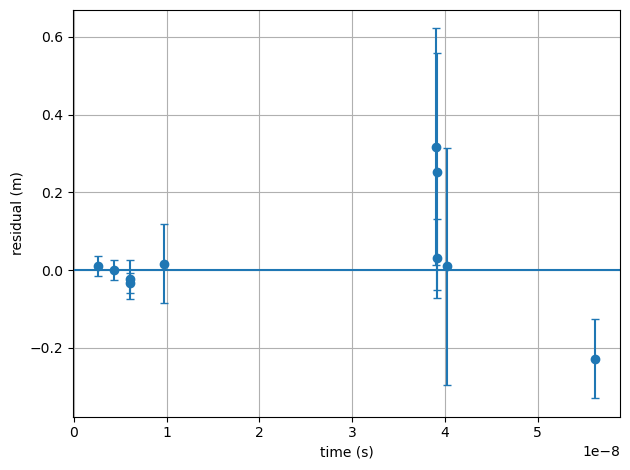

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.odr import ODR, Model, RealData
from scipy.stats import chi2

# constants / unit conversions
INCH_TO_M = 0.0254
NS_TO_S = 1e-9
SPEED_OF_LIGHT = 299_792_458  # m/s

# raw data
cable_length_in = np.array([18, 30.75, 42.5, 42.75, 72, 295.25, 302, 304, 305, 413.39])
cable_length_in_unc = 4*np.array([0.25, 0.25, 0.5, 0.25, 1, 1, 3, 3, 3, 1])

time_delay_ns = np.array([2.58, 4.32, 6, 6.08, 9.7, 39.2, 40.2, 39.2, 39, 56.2])
time_delay_ns_unc = np.array([0.35, 0.35, 0.5, 0.5, 0.5, 0.5, 1, 0.5, 0.5, 1])

# convert length to meters
cable_length_m = cable_length_in * INCH_TO_M
cable_length_m_unc = cable_length_in_unc * INCH_TO_M
# convert time to seconds
time_delay_s = time_delay_ns * NS_TO_S
time_delay_s_unc = time_delay_ns_unc * NS_TO_S

# model for both fits: distance = slope * time + intercept
# parameters = [slope_m_per_s, intercept_m]
def distance_from_time(parameters, time_values_s):
    slope_m_per_s = parameters[0]
    intercept_m = parameters[1]
    #computes predicted distance from each time value
    return slope_m_per_s * time_values_s + intercept_m

# weighted polyfit (uses only distance (y) uncertainty as weights, ignores time (x) uncertainty)
def fit_weighted_polyfit(time_s, distance_m, distance_m_unc):
    
    coefficients, covariance = np.polyfit(
        time_s,
        distance_m,
        deg=1, # fits a line with degree 1 (straight line)
        w=1 / distance_m_unc, # weight = 1/sigma_y
        cov=True
    )
    slope_m_per_s, intercept_m = coefficients
    
    #uncertainties found from the covariance matrix
    slope_unc = np.sqrt(covariance[0, 0])
    intercept_unc = np.sqrt(covariance[1, 1])

    return slope_m_per_s, intercept_m, slope_unc, intercept_unc

# odr fit (uses both time and distance uncertainties)
def fit_odr(time_s, distance_m, time_s_unc, distance_m_unc):
    
    #RealData stores x, y, and their uncertainties
    odr_data = RealData(time_s, distance_m, sx=time_s_unc, sy=distance_m_unc)
    odr_model = Model(distance_from_time)

    #initial guess for ODR model
    slope_guess = (distance_m[-1] - distance_m[0]) / (time_s[-1] - time_s[0])
    intercept_guess = distance_m.mean() - slope_guess * time_s.mean()
    initial_guess = [slope_guess, intercept_guess]

    #runs ODR solver
    odr_solver = ODR(odr_data, odr_model, beta0=initial_guess)
    odr_output = odr_solver.run()

    #best fit parameters from output
    slope_m_per_s, intercept_m = odr_output.beta
    slope_unc, intercept_unc = odr_output.sd_beta

    return slope_m_per_s, intercept_m, slope_unc, intercept_unc

# run fits
slope_poly_m_per_s, intercept_poly_m, slope_poly_unc, intercept_poly_unc = fit_weighted_polyfit(
    time_delay_s, cable_length_m, cable_length_m_unc
)

slope_odr_m_per_s, intercept_odr_m, slope_odr_unc, intercept_odr_unc = fit_odr(
    time_delay_s, cable_length_m, time_delay_s_unc, cable_length_m_unc
)

# print results
print("weighted polyfit (weights from distance uncertainty only):")
print(f"slope = {slope_poly_m_per_s:.3e} ± {slope_poly_unc:.1e} m/s")
print(f"intercept = {intercept_poly_m:.3e} ± {intercept_poly_unc:.1e} m")
print(f"v/c = {slope_poly_m_per_s/SPEED_OF_LIGHT:.3f} ± {slope_poly_unc/SPEED_OF_LIGHT:.3f}")

print("\nodr fit (uses time and distance uncertainties):")
print(f"slope = {slope_odr_m_per_s:.3e} ± {slope_odr_unc:.1e} m/s")
print(f"intercept = {intercept_odr_m:.3e} ± {intercept_odr_unc:.1e} m")
print(f"v/c = {slope_odr_m_per_s/SPEED_OF_LIGHT:.3f} ± {slope_odr_unc/SPEED_OF_LIGHT:.3f}")


#Calculating chi-square goodness of fit

number_of_points = len(time_delay_s)
number_of_parameters = 2
degrees_of_freedom = number_of_points - number_of_parameters

predicted_distance_poly_m = distance_from_time(
    [slope_poly_m_per_s, intercept_poly_m],
    time_delay_s
)

residuals_poly_m = cable_length_m - predicted_distance_poly_m

chi_square_poly = np.sum((residuals_poly_m / cable_length_m_unc) ** 2)
reduced_chi_square_poly = chi_square_poly / degrees_of_freedom

p_value_poly = chi2.sf(chi_square_poly, degrees_of_freedom)

print("\nchi-square for weighted polyfit (using y uncertainties):")
print(f"chi^2 = {chi_square_poly:.2f}")
print(f"ndof = {degrees_of_freedom}")
print(f"chi^2/ndof = {reduced_chi_square_poly:.2f}")
print(f"p-value = {p_value_poly:.3f}")


# plot
plt.figure()
plt.title("speed of light in cables")
plt.xlabel("time (s)")
plt.ylabel("distance (m)")

plt.errorbar(
    time_delay_s,
    cable_length_m,
    xerr=time_delay_s_unc,
    yerr=cable_length_m_unc,
    fmt='o',
    capsize=3,
    label="data"
)

time_fit_s = np.linspace(time_delay_s.min(), time_delay_s.max(), 200)

distance_fit_poly_m = distance_from_time([slope_poly_m_per_s, intercept_poly_m], time_fit_s)
distance_fit_odr_m = distance_from_time([slope_odr_m_per_s, intercept_odr_m], time_fit_s)

plt.plot(time_fit_s, distance_fit_poly_m, label="weighted polyfit")
plt.plot(time_fit_s, distance_fit_odr_m, label="odr")

plt.grid()
plt.legend()
plt.tight_layout()

out_path = '/Users/bryceolsen/Documents/Stuart Lab/cabledelay1.png'
plt.savefig(out_path, dpi=300, bbox_inches='tight')

plt.show()

#residual plot
predicted_distance = slope_odr_m_per_s * time_delay_s + intercept_odr_m
residuals = cable_length_m - predicted_distance

plt.figure()              # new, separate figure
plt.axhline(0)            # horizontal line at 0 residual
plt.errorbar(time_delay_s, residuals, yerr=cable_length_m_unc, fmt='o', capsize=3)
plt.xlabel("time (s)")
plt.ylabel("residual (m)")
plt.grid()
plt.tight_layout()

out_path = '/Users/bryceolsen/Documents/Stuart Lab/cabledelay2.png'
plt.savefig(out_path, dpi=300, bbox_inches='tight')

plt.show()
